TensorFlow Version: 2.20.0
Running on CPU Environment


Dataset Path: /root/.cache/kagglehub/datasets/mariaherrerot/aptos2019/versions/3

Training Class Distribution:

diagnosis
0    1434
2     808
1     300
4     234
3     154
Name: count, dtype: int64

Computed Class Weights:

{0: np.float64(0.4086471408647141), 1: np.float64(1.9533333333333334), 2: np.float64(0.7252475247524752), 3: np.float64(3.8051948051948052), 4: np.float64(2.5042735042735043)}
Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.

Class Indices Mapping:
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}

Loading EfficientNetB0 Backbone Model...


Model Summary Layout:



Model: "DR_Functional_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image_tensor (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pooling                  │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_core_1 (Dropout)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_128 (Dense)        │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_core_2 (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_classification_layer     │ (None, 5)              │           645 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Training Initializing...
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 650s 3s/step - accuracy: 0.5608 - loss: 1.3066 - val_accuracy: 0.6749 - val_loss: 0.8297 - learning_rate: 0.0010
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 638s 3s/step - accuracy: 0.6519 - loss: 1.0598 - val_accuracy: 0.7268 - val_loss: 0.7555 - learning_rate: 0.0010
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 627s 3s/step - accuracy: 0.6601 - loss: 1.0280 - val_accuracy: 0.7541 - val_loss: 0.6882 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.

Model Preserved to Disk File Successfully: diabetic_retinopathy_model.keras


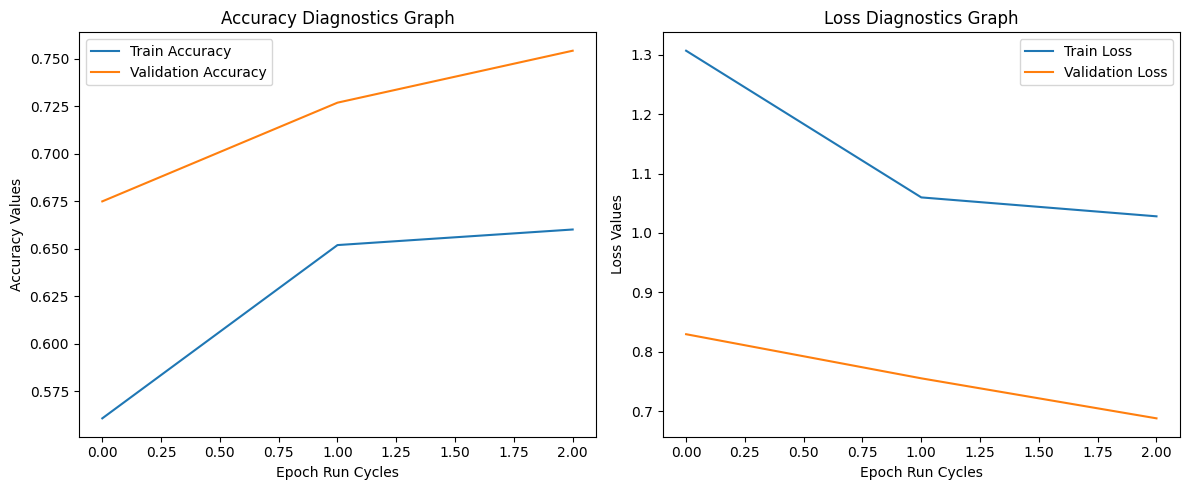


Evaluating Model Against Unseen Test Sub-dataset...

23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.7760 - loss: 0.6060

Test Dataset Final Accuracy: 0.7760
Test Dataset Final Loss: 0.6060
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step

Classification Evaluation Performance Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       199
           1       0.35      0.37      0.36        30
           2       0.67      0.71      0.69        87
           3       0.35      0.47      0.40        17
           4       0.67      0.30      0.42        33

    accuracy                           0.78       366
   macro avg       0.60      0.56      0.56       366
weighted avg       0.78      0.78      0.77       366



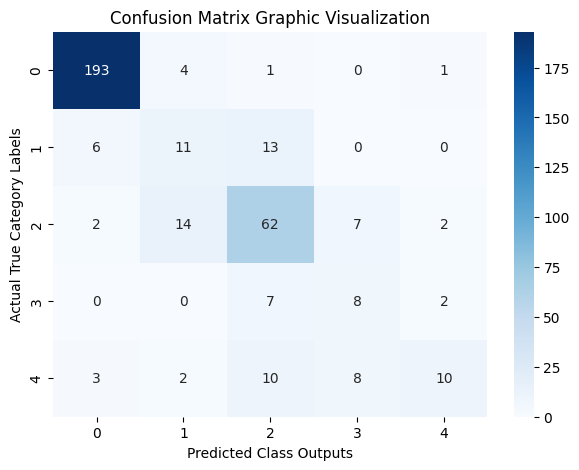

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_247']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


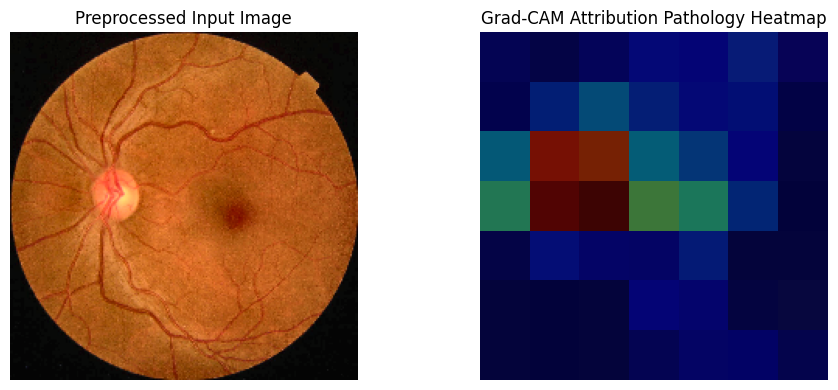


Project Framework Executed and Completed Successfully.


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

# Failsafe import for ImageDataGenerator across Keras 2 and Keras 3 architectures
try:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
except ImportError:
    from keras.src.legacy.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# CONFIGURATION
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 3
NUM_CLASSES = 5

MODEL_SAVE_PATH = "diabetic_retinopathy_model.keras"

# ============================================================
# GPU ALLOCATION INITIALIZATION
# ============================================================

print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU Available: {len(gpus)} device(s) detected.")
    # Dynamically allocate VRAM memory growth to prevent sudden VRAM allocation crashes
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
else:
    print("Running on CPU Environment")

# ============================================================
# DOWNLOAD DATASET
# ============================================================

print("\nDownloading Dataset via KaggleHub...\n")
kaggle_dataset_id = "mariaherrerot/aptos2019"
path = kagglehub.dataset_download(kaggle_dataset_id)
print("Dataset Path:", path)

# ============================================================
# DATASET PATHS & PATH VERIFICATION
# ============================================================

TRAIN_DIR = os.path.join(path, "train_images", "train_images")
VAL_DIR = os.path.join(path, "val_images", "val_images")
TEST_DIR = os.path.join(path, "test_images", "test_images")

# Structural verification check before moving forward
for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.exists(directory):
        raise FileNotFoundError(f"Critical Path Error: Directory missing -> {directory}")

# ============================================================
# LOAD CSV FILES & CLEAN EXTENSIONS
# ============================================================

train_df = pd.read_csv(os.path.join(path, "train_1.csv"))
val_df = pd.read_csv(os.path.join(path, "valid.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))

# Idiomatically strips existing extensions to guarantee no '.png.png' duplicate errors
for df in [train_df, val_df, test_df]:
    df['id_code'] = df['id_code'].astype(str).str.replace(".png", "", regex=False) + ".png"
    df['diagnosis'] = df['diagnosis'].astype(str)

# Ensure sample data alignment is true
sample_img_path = os.path.join(TRAIN_DIR, train_df['id_code'].iloc[0])
if not os.path.exists(sample_img_path):
    raise FileNotFoundError(f"Data Misalignment: Images not found inside {TRAIN_DIR}.")

print("\nTraining Class Distribution:\n")
print(train_df['diagnosis'].value_counts())

# ============================================================
# COMPUTE CLASS WEIGHTS
# ============================================================

y_ints = train_df['diagnosis'].astype(int).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_ints),
    y=y_ints
)
class_weights = dict(enumerate(class_weights))

print("\nComputed Class Weights:\n")
print(class_weights)

# ============================================================
# IMAGE PREPROCESSING FUNCTION (CLAHE Enhancement)
# ============================================================

def preprocess_image(img):
    # Ensure image is processing in normal uint8 format
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Apply Contrast Limited Adaptive Histogram Equalization
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Return float32 array in range [0, 255] (EfficientNet handles its own normalization internally)
    return img.astype(np.float32)

# ============================================================
# DATA GENERATORS
# ============================================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

# ============================================================
# FLOW GENERATORS
# ============================================================

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, directory=TRAIN_DIR, x_col='id_code', y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, directory=VAL_DIR, x_col='id_code', y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, directory=TEST_DIR, x_col='id_code', y_col='diagnosis',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print("\nClass Indices Mapping:")
print(train_generator.class_indices)

# ============================================================
# LOAD BACKBONE ARCHITECTURE
# ============================================================

print("\nLoading EfficientNetB0 Backbone Model...\n")
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

# ============================================================
# BUILD NETWORK MODEL (FUNCTIONAL API STYLE)
# ============================================================

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image_tensor")
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="dropout_core_1")(x)
x = Dense(128, activation='relu', name="hidden_dense_128")(x)
x = Dropout(0.3, name="dropout_core_2")(x)
outputs = Dense(NUM_CLASSES, activation='softmax', name="output_classification_layer")(x)

model = Model(inputs, outputs, name="DR_Functional_Model")

# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary Layout:\n")
model.summary()

# ============================================================
# TRAINING TRAINING OPTIMIZATION CALLBACKS
# ============================================================

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.000001, verbose=1)
]

# ============================================================
# MODEL RUN FIT
# ============================================================

print("\nTraining Initializing...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

# ============================================================
# MODEL PERSISTENCE SAVE
# ============================================================

model.save(MODEL_SAVE_PATH)
print(f"\nModel Preserved to Disk File Successfully: {MODEL_SAVE_PATH}")

# ============================================================
# VISUALIZE METRIC HISTORY RESULTS
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Metric Graph
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title("Accuracy Diagnostics Graph")
ax1.set_xlabel("Epoch Run Cycles")
ax1.set_ylabel("Accuracy Values")
ax1.legend()

# Loss Metric Graph
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title("Loss Diagnostics Graph")
ax2.set_xlabel("Epoch Run Cycles")
ax2.set_ylabel("Loss Values")
ax2.legend()

plt.tight_layout()
plt.show()

# ============================================================
# DATASET MODEL EVALUATION
# ============================================================

print("\nEvaluating Model Against Unseen Test Sub-dataset...\n")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Dataset Final Accuracy: {test_accuracy:.4f}")
print(f"Test Dataset Final Loss: {test_loss:.4f}")

# ============================================================
# EVALUATION METRICS PREDICTIONS
# ============================================================

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
target_names = list(train_generator.class_indices.keys())

print("\nClassification Evaluation Performance Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion Matrix Matrix Rendering
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix Graphic Visualization")
plt.xlabel("Predicted Class Outputs")
plt.ylabel("Actual True Category Labels")
plt.show()

# ============================================================
# FULLY DYNAMIC GRAD-CAM PIPELINE EXTRACTION
# ============================================================

LAST_CONV_LAYER_NAME = "top_conv"

def get_gradcam_heatmap(functional_model, img_array, last_conv_layer_name):
    # Dynamically find and extract the base model instance by class or name signature
    backbone_layer = None
    for layer in functional_model.layers:
        if isinstance(layer, Model) or "efficientnet" in layer.name.lower():
            backbone_layer = layer
            break

    if backbone_layer is None:
        raise ValueError("Graph error: Unable to dynamically extract core underlying Backbone Network.")

    # Target the designated target conv layer output directly inside the backbone
    base_grad_model = Model(
        inputs=backbone_layer.inputs,
        outputs=[backbone_layer.get_layer(last_conv_layer_name).output, backbone_layer.output]
    )

    # Calculate tape optimization forward propagation steps
    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = base_grad_model(img_array)

        # Dynamically forward-route outputs across all consecutive classification head layers
        x = base_outputs
        route_active = False
        for layer in functional_model.layers:
            if layer == backbone_layer:
                route_active = True
                continue
            if route_active:
                x = layer(x)

        predictions = x
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Differentiate target score with respect to target tensor feature maps
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU filtering normalization passes
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val != 0:
        heatmap /= max_val

    return heatmap.numpy()

# ============================================================
# GRAD-CAM DISPLAY TARGET RUN
# ============================================================

sample_batch = next(test_generator)
sample_image = sample_batch[0][0] if isinstance(sample_batch, tuple) else sample_batch[0]
img_batch_array = np.expand_dims(sample_image, axis=0)

heatmap_output = get_gradcam_heatmap(model, img_batch_array, LAST_CONV_LAYER_NAME)

# Display Heatmap Graph Results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image.astype(np.uint8))
plt.title("Preprocessed Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_image.astype(np.uint8))
plt.imshow(heatmap_output, cmap='jet', alpha=0.45)
plt.title("Grad-CAM Attribution Pathology Heatmap")
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# SINGLE EXTERNAL IMAGE INFERENCE PIPELINE
# ============================================================

def predict_image(image_path):
    if not os.path.exists(image_path):
        print(f"File Path Error: Image not found at {image_path}")
        return

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_image(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    class_labels = {
        0: "No DR",
        1: "Mild",
        2: "Moderate",
        3: "Severe",
        4: "Proliferative DR"
    }

    print("\nExternal Target Prediction Result")
    print("---------------------------------")
    print("Predicted Diagnostics Class Label:", class_labels[predicted_class])
    print("Inference Metric Confidence Score:", round(confidence * 100, 2), "%")

# ============================================================
# SYSTEM COMPLETE TERMINATION
# ==========================================0-==================
print("\nProject Framework Executed and Completed Successfully.")